In [10]:
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries loaded ✅")

Libraries loaded ✅


In [11]:
df = pd.read_csv('MUP_DPR_RY26_P04_V10_DY24_NPIBN.csv', nrows=500000)
print(f"Sample loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"\nColumns: {df.columns.tolist()}")

Sample loaded: 500,000 rows, 22 columns

Columns: ['Prscrbr_NPI', 'Prscrbr_Last_Org_Name', 'Prscrbr_First_Name', 'Prscrbr_City', 'Prscrbr_State_Abrvtn', 'Prscrbr_State_FIPS', 'Prscrbr_Type', 'Prscrbr_Type_Src', 'Brnd_Name', 'Gnrc_Name', 'Tot_Clms', 'Tot_30day_Fills', 'Tot_Day_Suply', 'Tot_Drug_Cst', 'Tot_Benes', 'GE65_Sprsn_Flag', 'GE65_Tot_Clms', 'GE65_Tot_30day_Fills', 'GE65_Tot_Drug_Cst', 'GE65_Tot_Day_Suply', 'GE65_Bene_Sprsn_Flag', 'GE65_Tot_Benes']


/var/folders/wx/slj5n9mx5_x5hpgtg68lnd_w0000gn/T/ipykernel_57872/916191343.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('MUP_DPR_RY26_P04_V10_DY24_NPIBN.csv', nrows=500000)


In [12]:
print("=== FIRST 5 ROWS ===")
display(df.head())

print("\n=== NULL VALUES ===")
print(df.isnull().sum())

=== FIRST 5 ROWS ===


,Prscrbr_NPI,Prscrbr_Last_Org_Name,Prscrbr_First_Name,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_State_FIPS,Prscrbr_Type,Prscrbr_Type_Src,Brnd_Name,Gnrc_Name,...,Tot_Day_Suply,Tot_Drug_Cst,Tot_Benes,GE65_Sprsn_Flag,GE65_Tot_Clms,GE65_Tot_30day_Fills,GE65_Tot_Drug_Cst,GE65_Tot_Day_Suply,GE65_Bene_Sprsn_Flag,GE65_Tot_Benes
0,1003000126,Enkeshafi,Ardalan,Bethesda,MD,24,Internal Medicine,Claim-Specialty,Abrysvo,"Rsv Vacc, Pref A And Pref B/Pf",...,20,5994.01,20.0,NaN,20.0,20.0,5994.01,20.0,NaN,20.0
1,1003000126,Enkeshafi,Ardalan,Bethesda,MD,24,Internal Medicine,Claim-Specialty,Boostrix Tdap,"Diphth,pertuss(Acell),tet Vac",...,12,648.26,12.0,NaN,12.0,12.0,648.26,12.0,NaN,12.0
2,1003000142,Khalil,Rashid,Toledo,OH,39,Anesthesiology,Claim-Specialty,Acetaminophen-Codeine,Acetaminophen With Codeine,...,628,362.48,11.0,#,NaN,NaN,NaN,NaN,*,NaN
3,1003000142,Khalil,Rashid,Toledo,OH,39,Anesthesiology,Claim-Specialty,Amitriptyline Hcl,Amitriptyline Hcl,...,1410,271.17,16.0,NaN,30.0,30.0,150.18,900.0,*,NaN
4,1003000142,Khalil,Rashid,Toledo,OH,39,Anesthesiology,Claim-Specialty,Baclofen,Baclofen,...,1395,333.35,26.0,NaN,33.0,33.0,222.14,975.0,#,NaN



=== NULL VALUES ===
Prscrbr_NPI                   0
Prscrbr_Last_Org_Name         0
Prscrbr_First_Name            0
Prscrbr_City                  0
Prscrbr_State_Abrvtn          0
Prscrbr_State_FIPS            0
Prscrbr_Type                  0
Prscrbr_Type_Src              0
Brnd_Name                     0
Gnrc_Name                     0
Tot_Clms                      0
Tot_30day_Fills               0
Tot_Day_Suply                 0
Tot_Drug_Cst                  0
Tot_Benes                271695
GE65_Sprsn_Flag          275530
GE65_Tot_Clms            224470
GE65_Tot_30day_Fills     224470
GE65_Tot_Drug_Cst        224470
GE65_Tot_Day_Suply       224470
GE65_Bene_Sprsn_Flag      60389
GE65_Tot_Benes           439611
dtype: int64


In [13]:
top10 = (df.groupby(['Prscrbr_NPI', 'Prscrbr_Last_Org_Name', 'Prscrbr_Type'])['Tot_Drug_Cst']
           .sum()
           .reset_index()
           .sort_values('Tot_Drug_Cst', ascending=False)
           .head(10))

top10['Tot_Drug_Cst'] = top10['Tot_Drug_Cst'].round(2)
print("TOP 10 PRESCRIBERS BY TOTAL DRUG COST:")
display(top10)

TOP 10 PRESCRIBERS BY TOTAL DRUG COST:


,Prscrbr_NPI,Prscrbr_Last_Org_Name,Prscrbr_Type,Tot_Drug_Cst
8618,1003840778,Mays,Family Practice,41690176.03
1352,1003101429,Pettijohn,Hematology-Oncology,17660241.43
12689,1013086420,Baron,Hematology-Oncology,14841387.65
5717,1003447368,Baker,Nurse Practitioner,13902581.59
3033,1003235391,Sochacki,Hematology-Oncology,13642124.74
14515,1013214535,Guo,Hematology-Oncology,12970420.06
737,1003052788,Anesi,Ophthalmology,12815139.91
15500,1013297167,Butler,Hematology-Oncology,11707871.27
11533,1013002880,Sai,Hematology-Oncology,9719040.72
2219,1003171778,Ravilla,Hematology-Oncology,9102070.46


In [14]:
spending_by_npi = df.groupby('Prscrbr_NPI')['Tot_Drug_Cst'].sum()

average   = spending_by_npi.mean()
std       = spending_by_npi.std()
threshold = average + 2 * std

print(f"Average spending per prescriber:  ${average:,.2f}")
print(f"Standard deviation:               ${std:,.2f}")
print(f"Anomaly threshold (mean+2σ):      ${threshold:,.2f}")

anomalies = spending_by_npi[spending_by_npi > threshold].reset_index()
anomalies.columns = ['Prscrbr_NPI', 'Tot_Drug_Cst']
anomalies = anomalies.sort_values('Tot_Drug_Cst', ascending=False)

print(f"\nAnomalous prescribers:  {len(anomalies):,}")
print(f"Share of total:         {len(anomalies)/len(spending_by_npi)*100:.1f}%")
display(anomalies.head(10))

Average spending per prescriber:  $196,534.89
Standard deviation:               $673,674.39
Anomaly threshold (mean+2σ):      $1,543,883.66

Anomalous prescribers:  510
Share of total:         2.4%


,Prscrbr_NPI,Tot_Drug_Cst
161,1003840778,41690176.03
42,1003101429,17660241.43
339,1013086420,14841387.65
106,1003447368,13902581.59
81,1003235391,13642124.74
404,1013214535,12970420.06
15,1003052788,12815139.91
427,1013297167,11707871.27
291,1013002880,9719040.72
63,1003171778,9102070.46


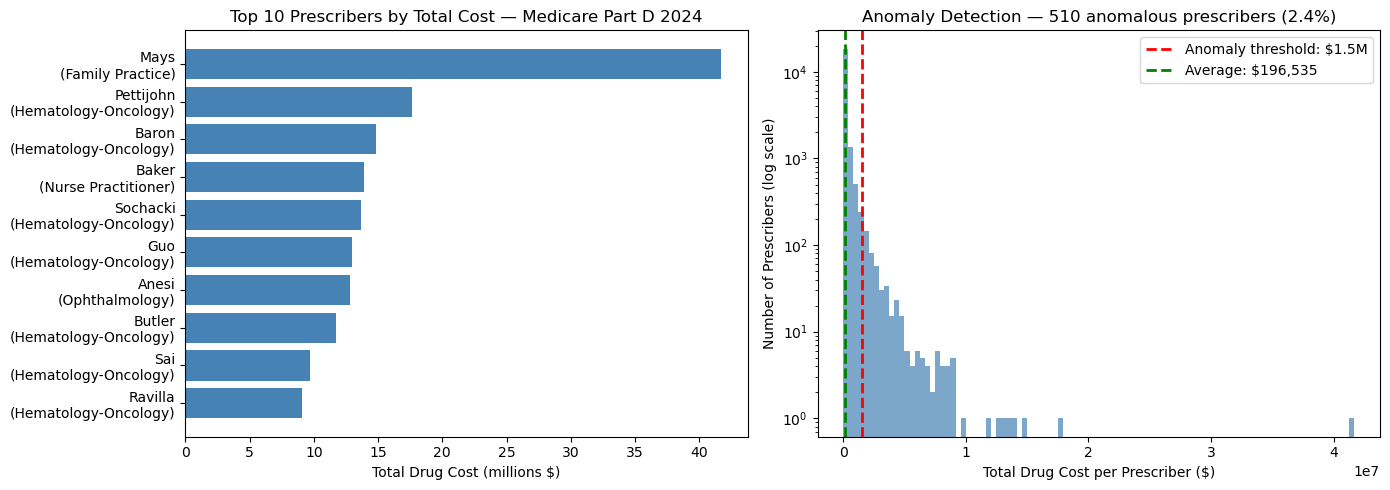

Chart saved ✅


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — Top 10 prescribers by cost
top10_plot = top10.copy()
top10_plot['Label'] = (top10_plot['Prscrbr_Last_Org_Name'] +
                       '\n(' + top10_plot['Prscrbr_Type'] + ')')
axes[0].barh(top10_plot['Label'],
             top10_plot['Tot_Drug_Cst'] / 1_000_000,
             color='steelblue')
axes[0].set_xlabel('Total Drug Cost (millions $)')
axes[0].set_title('Top 10 Prescribers by Total Cost — Medicare Part D 2024')
axes[0].invert_yaxis()

# Chart 2 — Spending distribution with anomaly threshold
axes[1].hist(spending_by_npi, bins=100, color='steelblue', alpha=0.7, log=True)
axes[1].axvline(threshold, color='red', linestyle='--', linewidth=2,
                label=f'Anomaly threshold: ${threshold/1e6:.1f}M')
axes[1].axvline(average, color='green', linestyle='--', linewidth=2,
                label=f'Average: ${average:,.0f}')
axes[1].set_xlabel('Total Drug Cost per Prescriber ($)')
axes[1].set_ylabel('Number of Prescribers (log scale)')
axes[1].set_title(f'Anomaly Detection — {len(anomalies):,} anomalous prescribers (2.4%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('cms_anomaly_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✅")

In [16]:
print("=" * 58)
print("SUMMARY — CMS Medicare Part D Anomaly Analysis")
print("=" * 58)
print(f"Dataset:                  CMS Medicare Part D 2024")
print(f"Sample analyzed:          500,000 records")
print(f"Unique prescribers:       {len(spending_by_npi):,}")
print(f"Average spending:         ${average:,.2f}")
print(f"Anomaly threshold:        ${threshold:,.2f}")
print(f"Anomalous prescribers:    {len(anomalies):,} ({len(anomalies)/len(spending_by_npi)*100:.1f}%)")
print(f"Top outlier:              Mays (Family Practice) — ${top10.iloc[0]['Tot_Drug_Cst']:,.0f}")
print("=" * 58)
print("Analysis complete ✅")

SUMMARY — CMS Medicare Part D Anomaly Analysis
Dataset:                  CMS Medicare Part D 2024
Sample analyzed:          500,000 records
Unique prescribers:       21,025
Average spending:         $196,534.89
Anomaly threshold:        $1,543,883.66
Anomalous prescribers:    510 (2.4%)
Top outlier:              Mays (Family Practice) — $41,690,176
Analysis complete ✅
